<a href="https://colab.research.google.com/github/sthefany-vg/Decision-Aid/blob/main/LAB1_MVs_Imputation_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAPPC – LAB 1
## Hierarchical Cluustering-based Missing Value Imputation

In this notebook you will:

1. Load a prepared dataset  
2. Explore missing values  
3. Apply Hierarchical Clustering-based imputation  
5. Save the imputed dataset

We assume:
- The dataset is already cleaned (columns/rows filtered)
- Outcome has 3 classes (0,1,2)

## 0) Setup


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

## 1) Load Dataset


In [ ]:
# === TODO: set your file path and sheet name ===
# Usamos el archivo que exportamos al final del paso anterior
file_path = 'Dataset_DAPPC_2026_Cleaned.xlsx'
sheet_name = 'Dataset_v1'

# Cargamos el DataFrame limpio
df = pd.read_excel(file_path, sheet_name=sheet_name)

print("Initial shape:", df.shape)
df.head()

Initial shape: (3893, 75)


,subject_id,hadm_id,stay_id,ICU,ICU_intime,ICU_outtime,gender,age,weight,charlson_comorbidity_index,...,std_mean_airway_pressure,first_plateau_pressure,std_plateau_pressure,vent_duration_hours,outcome,comorb_cardiac_cardiovascular,comorb_respiratory_pulmonary,comorb_metabolic_endocrine_renal,comorb_neurological_neuromuscular_psychiatric,comorb_systemic_immune_oncologic
0,13710366,26676995,36043579,1,2172-04-05 04:00:00,2172-04-09 08:17:22,1,66,113.3,3,...,1.923269,19.0,1.909727,96.0,2,0,0,1,0,0
1,12970079,23949170,36004625,1,2164-12-22 19:48:19,2165-01-03 21:30:54,1,53,106.7,5,...,6.393488,10.0,8.337289,230.0,1,0,1,1,0,0
2,17682100,22097504,34901461,1,2173-08-23 01:12:00,2173-08-27 21:28:52,0,66,46.1,6,...,2.184796,17.0,1.224745,34.0,1,0,0,1,0,0
3,15545849,24922530,39025631,3,2172-08-02 16:32:00,2172-09-09 12:44:11,1,49,106.0,1,...,4.233572,11.0,4.877563,399.0,2,1,0,1,1,0
4,10288279,21750307,34078845,1,2114-09-07 20:19:42,2114-09-15 13:24:09,0,77,49.3,7,...,1.405487,17.0,3.239768,155.0,2,1,0,1,0,1


## 2) Column Index Table


In [ ]:
display(pd.DataFrame({
    "index": np.arange(df.shape[1]),
    "column_name": df.columns,
    "dtype": df.dtypes
}))

,index,column_name,dtype
subject_id,0,subject_id,int64
hadm_id,1,hadm_id,int64
stay_id,2,stay_id,int64
ICU,3,ICU,int64
ICU_intime,4,ICU_intime,object
...,...,...,...
comorb_cardiac_cardiovascular,70,comorb_cardiac_cardiovascular,int64
comorb_respiratory_pulmonary,71,comorb_respiratory_pulmonary,int64
comorb_metabolic_endocrine_renal,72,comorb_metabolic_endocrine_renal,int64
comorb_neurological_neuromuscular_psychiatric,73,comorb_neurological_neuromuscular_psychiatric,int64


## 3) Explore Missing Values

In [ ]:
# Total missing values (global)
print("Total missing values:", df.isna().sum().sum())

# Missing per column: count + percentage
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2)
})

# Mostra solo colonne con almeno un missing
missing_table = missing_table[missing_table["missing_count"] > 0] \
                    .sort_values("missing_%", ascending=False)

display(missing_table)


Total missing values: 906


,missing_count,missing_%
weight,177,4.55
std_plateau_pressure,140,3.60
first_plateau_pressure,137,3.52
first_temperature,58,1.49
std_PTT,57,1.46
first_PTT,57,1.46
std_PT,54,1.39
std_temperature,53,1.36
first_PT,53,1.36
std_PEEP,34,0.87


## 4) Apply Hierarchical clustering-based Imputation

Adopting hierarchical clustering as MVs imputations works as follows:
1. Identify input features (Only clinically meaningful numeric variables should be imputed) and their type (continous, categorical or integer);
2. Define the TRS (subjects without any missing value)
3. Data normalization (min-max scaling applied to the TRS);
4. Dendrogram construction (linkage and dendrogram functions);
5. Cluster identifications (cut the dendrogram and assign the subjects of the TRS to their cluster);
6. Centroids computation (for each cluster compute the centroid);
7. For each subject with at least one MV:
   
   a) Compute the distances wit the centroids;
   
   b) Assign the subject with MVs to its cluster (the closest one);
   
   c) Impute the MVs according to the type of feature (mean value + noise  for continous variables, random value between the 40th and 60th percentile for integer variables, majority voting for categorical variables).

Notes:
- The centroids and the distances must be computed on the normalized data.
- The imputation must be performed on the original values of the features (not the normalized ones!).
- Try to cut the dendrogram in order to obtain between 30 and 35 clusters.

In [ ]:
# ============================================================
# 1. Define variable groups: you should obtain the names of the features divided by type
# ============================================================

# Variables continuas: Parámetros de laboratorio y signos vitales medidos con decimales (float64)
continuous_vars = [
    "weight", "first_pCO2", "std_pCO2", "first_pH", "std_pH", "first_pO2", "std_pO2",
    "first_PT", "std_PT", "first_PTT", "std_PTT", "std_chloride", "first_creatinine",
    "std_creatinine", "first_glycemia", "std_glycemia", "first_hemoglobin", "std_hemoglobin",
    "first_phosphate", "std_phosphate", "std_platelets", "first_potassium", "std_potassium",
    "std_sodium", "first_wbc", "std_wbc", "first_diastolic_blood_pressure", "std_diastolic_blood_pressure",
    "first_mean_blood_pressure", "std_mean_blood_pressure", "first_systolic_blood_pressure",
    "std_systolic_blood_pressure", "first_heart_rate", "std_heart_rate", "first_respiratory_rate",
    "std_respiratory_rate", "first_temperature", "std_temperature", "first_PEEP", "std_PEEP",
    "first_PIP", "std_PIP", "first_mean_airway_pressure", "std_mean_airway_pressure",
    "first_plateau_pressure", "std_plateau_pressure", "vent_duration_hours", "sedative_duration_hours"
]

# Variables enteras (Integer): Puntuaciones clínicas de escalas de gravedad o recuentos (int64)
integer_vars = [
    "age", "charlson_comorbidity_index", "gcs", "sofa", "sirs", "sapsii",
    "comorb_total", "first_chloride", "first_platelets", "first_sodium"
]

# Variables categóricas: Flags binarios (0 o 1) como el género, uso de fármacos y las 5 categorías de comorbilidades
categorical_vars = [
    "gender", "vasopressors", "sedatives", "neuromuscular_blockers", "steroids", "opioids",
    "comorb_cardiac_cardiovascular", "comorb_respiratory_pulmonary",
    "comorb_metabolic_endocrine_renal", "comorb_neurological_neuromuscular_psychiatric",
    "comorb_systemic_immune_oncologic"
]

# Combinación ordenada de todas las características que entrarán al algoritmo de clustering
input_features = continuous_vars + integer_vars + categorical_vars

In [ ]:
# ============================================================
# 2. Split subjects into:
#    - TRS: subjects without missing values
#    - subjects with missing values
# ============================================================

# --- SOLUCIÓN AL KEYERROR ---
# Si 'comorb_total' no está en el DataFrame, la calculamos sumando las 5 categorías clínicas
if 'comorb_total' not in df.columns:
    cat_cols = [col for col in df.columns if col.startswith('comorb_')]
    df['comorb_total'] = df[cat_cols].sum(axis=1)

# Ahora sí, extraemos las características de entrada sin errores
X = df[input_features].copy()

# X_trs: Filtramos las filas eliminando cualquiera que tenga un NaN en sus características
X_trs = X.dropna()

# X_missing: Nos quedamos con las filas que tienen AL MENOS un NaN (usamos el índice inverso)
X_missing = X[X.isna().any(axis=1)]

# Check how many subjects are in each set
print("TRS subjects:", X_trs.shape[0])
print("Subjects with MVs:", X_missing.shape[0])

# ============================================================
# 3. Normalize TRS subjects
# ============================================================
scaler = MinMaxScaler()

# fit_transform aprende los mínimos y máximos del TRS y escala los datos entre 0 y 1
X_trs_scaled = pd.DataFrame(
    scaler.fit_transform(X_trs),
    columns=X_trs.columns,
    index=X_trs.index
)

TRS subjects: 3378
Subjects with MVs: 515


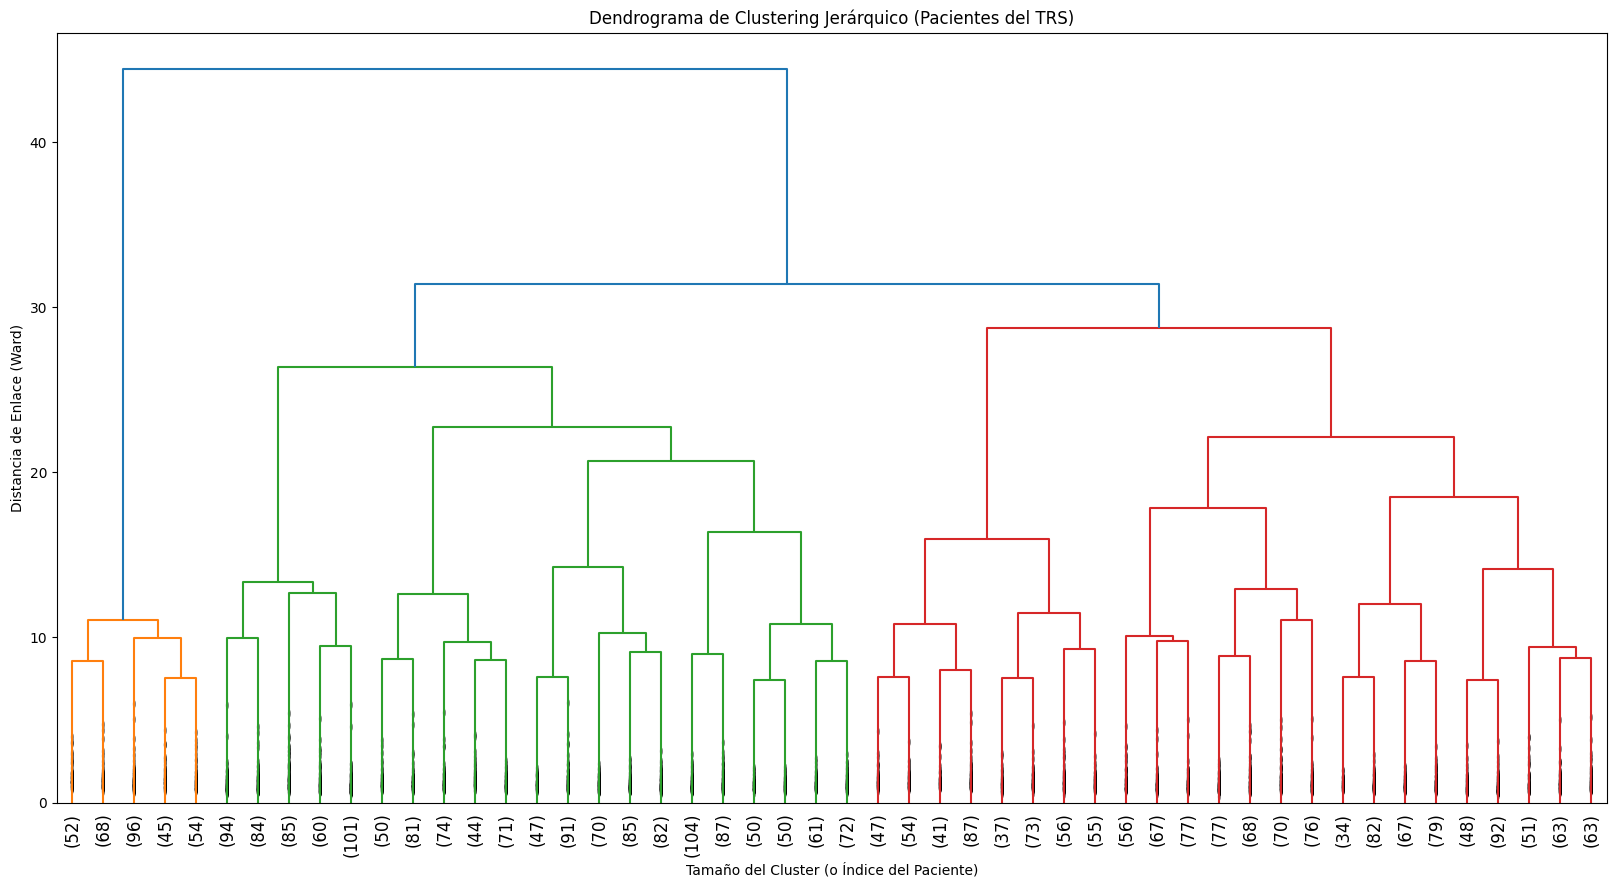

In [ ]:
# Apply clustering-based imputation
# Helpful functions and classes:
# - linkage (read the docs)
# - dendrogram (read the docs)
# - fcluster (read the docs)

# ============================================================
# 4. Construct the dendrogram
# ============================================================
# Usamos el dataset NORMALIZADO (X_trs_scaled).
# El método de Ward es ideal para encontrar estructuras esféricas y compactas de pacientes.
Z = linkage(X_trs_scaled, method='ward', metric='euclidean')

plt.figure(figsize=(20, 10))

# Graficamos el dendrograma.
# truncate_mode='lastp' y p=50 evitan que el gráfico colapse con 4000 líneas verticales,
# mostrando un resumen limpio de las últimas 50 uniones de ramas.
dendrogram(
    Z,
    truncate_mode='lastp',
    p=50,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True
)

plt.title("Dendrograma de Clustering Jerárquico (Pacientes del TRS)")
plt.xlabel("Tamaño del Cluster (o Índice del Paciente)")
plt.ylabel("Distancia de Enlace (Ward)")
plt.show()


In [ ]:
# ============================================================
# 5. Identify clusters in the TRS
# ============================================================
n_clusters = 33
cluster_labels = fcluster(Z, t=n_clusters, criterion='maxclust')

X_trs_scaled["cluster"] = cluster_labels
X_trs["cluster"] = cluster_labels

print("Number of clusters found:", len(np.unique(cluster_labels)))

Number of clusters found: 33


/tmp/ipykernel_1314/2188777112.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_trs["cluster"] = cluster_labels


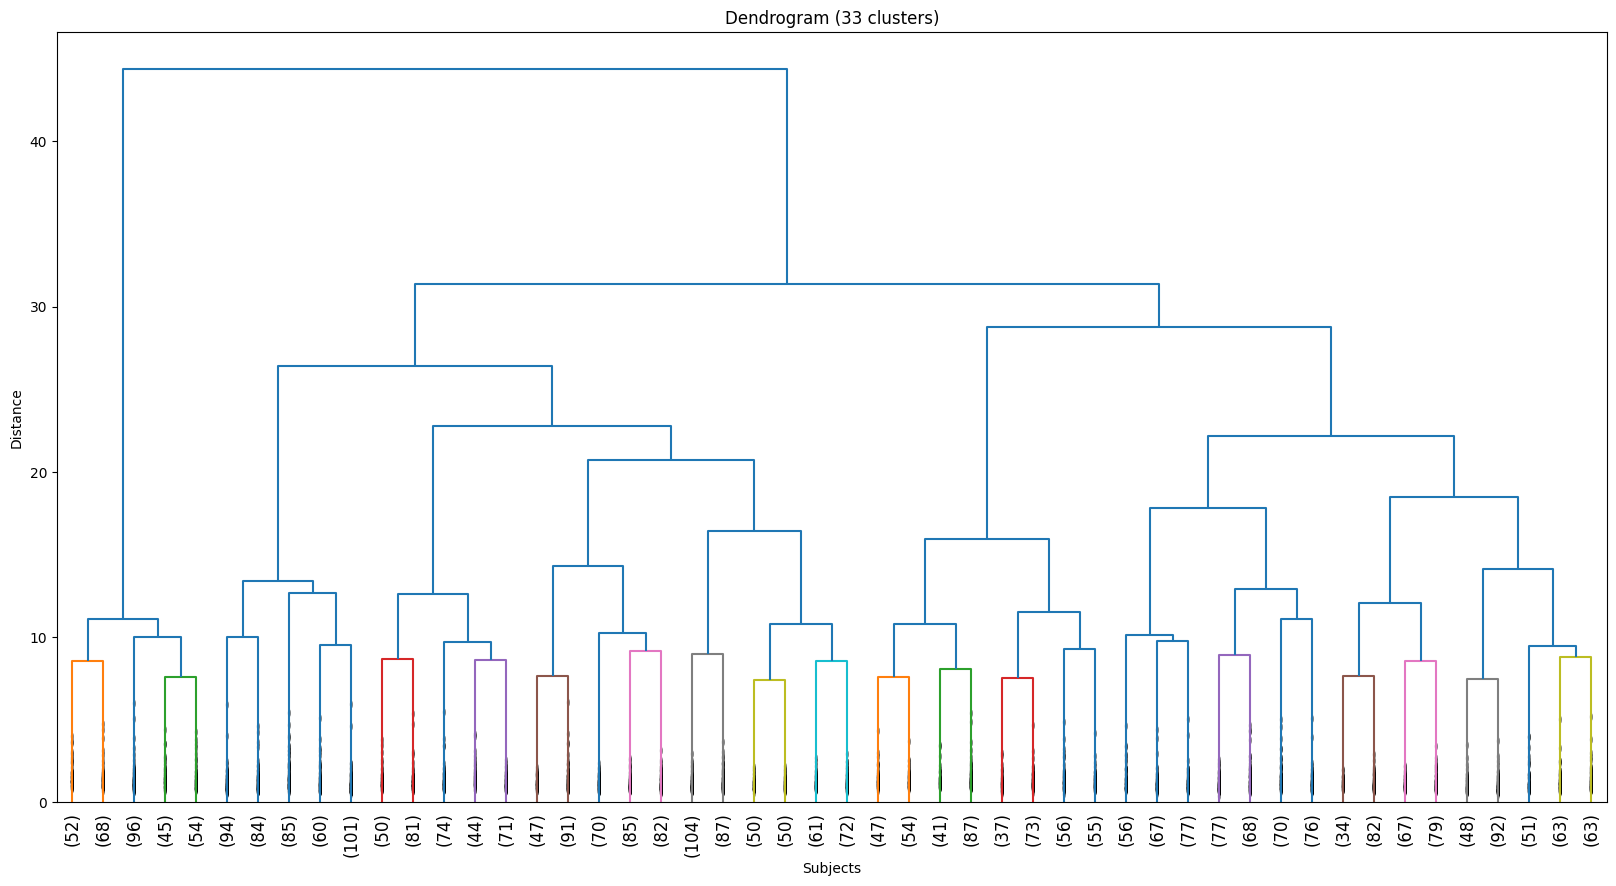

In [ ]:
# ============================================================
# Look the dendrogram with clusters defined
# ============================================================
plt.figure(figsize=(20, 10))

# Calculamos el umbral de color automáticamente basándonos en la altura de las uniones de Z
# Esto asegura que las ramas se coloreen reflejando fielmente la separación de tus clusters
max_d = Z[-(n_clusters-1), 2] if len(Z) >= n_clusters else 0

dendrogram(
    Z,
    truncate_mode='lastp',
    p=50,                  # Muestra las últimas 50 ramas unidas
    color_threshold=max_d, # Altura de corte para colorear los clusters diferenciados
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True
)

plt.title(f"Dendrogram ({n_clusters} clusters)")
plt.xlabel("Subjects")
plt.ylabel("Distance")
plt.show()

In [ ]:
# ============================================================
# 6. Compute centroids (on normalized data)
# ============================================================
# Agrupamos por la columna 'cluster' y calculamos la media para cada uno de ellos
centroids_scaled = X_trs_scaled.groupby("cluster").mean()

In [ ]:
# ============================================================
# 7. Impute subjects with missing values
# ============================================================
X_imputed = X.copy()

# Loop over subjects with missing values
for subject_idx in X_missing.index:

    # Current subject (extraemos la fila original del paciente actual)
    subject = X_missing.loc[subject_idx]

    # Normalize subject using scaler fitted on TRS
    subject_scaled = pd.DataFrame(
        scaler.transform(subject.to_frame().T),
        columns=input_features,
        index=[subject_idx]
    )

    # Keep only observed (non NAN) variables (las variables que SÍ están medidas)
    observed_vars = subject.dropna().index.tolist()

    # Compare subject and centroids only on observed variables
    subject_observed = subject_scaled.loc[subject_idx, observed_vars]
    centroids_observed = centroids_scaled[observed_vars]

    # Manhattan distance from all centroids (suma de las diferencias absolutas)
    distances = np.sum(np.abs(centroids_observed - subject_observed), axis=1)

    # Identify the closest cluster (el del índice de distancia mínima)
    # sumamos +1 porque fcluster etiqueta de 1 a 33, mientras idxmin() devuelve de 1 a 33 gracias a groupby
    closest_cluster = distances.idxmin()

    # Extract subjects of that cluster (buscamos en el TRS original los pacientes de ese grupo)
    cluster_subjects = X_trs[X_trs["cluster"] == closest_cluster]

    # Identify missing variables for the current subject (las columnas vacías a imputar)
    missing_vars = subject[subject.isna()].index.tolist()

    # Impute MVs according to the type of each feature (3 cases)
    for var in missing_vars:
        if var in continuous_vars:
            # Caso a: Media del cluster + un pequeño ruido Gaussiano (evita valores idénticos artificiales)
            mean_val = cluster_subjects[var].mean()
            std_val = cluster_subjects[var].std()
            # Si la desviación es nan (un solo elemento en el cluster), el ruido es 0
            noise = np.random.normal(0, 0.01 * std_val) if not np.isnan(std_val) else 0
            X_imputed.loc[subject_idx, var] = mean_val + noise

        elif var in integer_vars:
            # Caso b: Valor aleatorio entre el percentil 40 y 60 del cluster
            p40 = cluster_subjects[var].quantile(0.40)
            p60 = cluster_subjects[var].quantile(0.60)
            # Aseguramos un entero en ese rango. Si p40 == p60, tomamos p40 de forma entera
            val = np.random.randint(low=int(p40), high=int(p60) + 1) if p40 < p60 else int(p40)
            X_imputed.loc[subject_idx, var] = val

        elif var in categorical_vars:
            # Caso c: Voto de la mayoría (Moda)
            X_imputed.loc[subject_idx, var] = cluster_subjects[var].mode()[0]

# ============================================================
# 8. Rebuild final dataset
# ============================================================
df_final = df.copy()
df_final[input_features] = X_imputed[input_features]

# Verificación de oro: asegurar que ya no existen nulos en todo el archivo
print("Valores faltantes restantes en df_final:", df_final[input_features].isna().sum().sum())


Valores faltantes restantes en df_final: 0


## 5) Final saving

In [ ]:
## 5) Final saving
# Save the imputed dataset (clustering on all patients) into a new Excel sheet (Not a new file!)

file_path = 'Dataset_DAPPC_2026_Cleaned.xlsx'
new_sheet_name = "Dataset_step_3c"

# Usamos mode='a' (append) para abrir el archivo existente y agregar la nueva pestaña
# if_sheet_exists='replace' asegura que si vuelves a correr la celda, se actualice la hoja sin dar error
with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df_final.to_excel(writer, sheet_name=new_sheet_name, index=False)

print(f"¡Éxito! Los datos imputados por clustering global se han guardado en la hoja: '{new_sheet_name}'")

¡Éxito! Los datos imputados por clustering global se han guardado en la hoja: 'Dataset_step_3c'


In [ ]:
# Save the imputed dataset (clustering on all patients) into a new Excel sheet (Not a new file!)
new_sheet_name = "Dataset_step_3c"


---
## Hierarchical Clustering-based Missing Value Imputation by Outcome Class

In this section we perform clustering-based imputation **separately for each outcome class (0 / 1 / 2)**.

Why?
- Patients from different outcome classes may have different clinical distributions.
- Imputing within class preserves intra-class similarity.


In [ ]:
# Clusteringimputation separately for each outcome class

# Idea:
# - split patients by outcome class
# - apply the SAME normalization + clustering-based imputation inside each class subset
# - concatenate all imputed subsets
...


In [ ]:
# Clustering imputation separately for each outcome class

# Lista para almacenar los DataFrames ya imputados de cada clase
imputed_subsets = []

# Iteramos de forma independiente por cada una de las clases únicas del outcome (0, 1, 2)
for outcome_class in sorted(df['outcome'].unique()):
    print(f"\n>>> PROCESANDO PACIENTES DE LA CLASE DE OUTCOME: {outcome_class} <<<")

    # 1. Filtramos el DataFrame original para quedarnos solo con la clase actual
    df_class = df[df['outcome'] == outcome_class].copy()

    # 2. Separamos las características de entrada para esta clase
    X_class = df_class[input_features].copy()

    # Aseguramos la existencia de 'comorb_total' si fuera necesario
    if 'comorb_total' not in X_class.columns:
        cat_cols = [col for col in X_class.columns if col.startswith('comorb_')]
        X_class['comorb_total'] = X_class[cat_cols].sum(axis=1)

    # 3. Dividimos en TRS (completos) y pacientes con MVs para ESTA clase
    X_trs_class = X_class.dropna().copy()
    X_missing_class = X_class[X_class.isna().any(axis=1)].copy()

    print(f"   [Clase {outcome_class}] Pacientes TRS: {X_trs_class.shape[0]} | Pacientes con MVs: {X_missing_class.shape[0]}")

    # Si no hay pacientes con MVs en esta clase, saltamos la imputación para este grupo
    if X_missing_class.empty:
        imputed_subsets.append(df_class)
        continue

    # 4. Normalizamos el TRS de la clase actual
    scaler_class = MinMaxScaler()
    X_trs_scaled_class = pd.DataFrame(
        scaler_class.fit_transform(X_trs_class),
        columns=X_trs_class.columns,
        index=X_trs_class.index
    )

    # 5. Construimos el dendrograma jerárquico específico de la clase
    Z_class = linkage(X_trs_scaled_class, method='ward', metric='euclidean')

    # 6. Identificamos los clusters dentro de la clase (ajustamos n_clusters según el tamaño de la muestra)
    # Como hay menos pacientes por clase, reducimos proporcionalmente a 15-20 clusters para no atomizar los grupos
    n_clusters_class = 20
    cluster_labels_class = fcluster(Z_class, t=n_clusters_class, criterion='maxclust')

    X_trs_scaled_class["cluster"] = cluster_labels_class
    X_trs_class["cluster"] = cluster_labels_class

    # 7. Calculamos los centroides específicos de la clase
    centroids_scaled_class = X_trs_scaled_class.groupby("cluster").mean()

    # 8. Bucle de imputación para los pacientes faltantes de esta clase específica
    X_imputed_class = X_class.copy()

    for subject_idx in X_missing_class.index:
        subject = X_missing_class.loc[subject_idx]

        # Escalamiento del paciente usando el scaler de su propia clase
        subject_scaled = pd.DataFrame(
            scaler_class.transform(subject.to_frame().T),
            columns=input_features,
            index=[subject_idx]
        )

        observed_vars = subject.dropna().index.tolist()
        subject_observed = subject_scaled.loc[subject_idx, observed_vars]
        centroids_observed = centroids_scaled_class[observed_vars]

        # Distancia de Manhattan contra los centroides de su clase
        distances = np.sum(np.abs(centroids_observed - subject_observed), axis=1)
        closest_cluster = distances.idxmin()

        cluster_subjects = X_trs_class[X_trs_class["cluster"] == closest_cluster]
        missing_vars = subject[subject.isna()].index.tolist()

        # Aplicamos las 3 reglas de imputación utilizando la estadística del cluster hermano
        for var in missing_vars:
            if var in continuous_vars:
                mean_val = cluster_subjects[var].mean()
                std_val = cluster_subjects[var].std()
                noise = np.random.normal(0, 0.01 * std_val) if not np.isnan(std_val) else 0
                X_imputed_class.loc[subject_idx, var] = mean_val + noise
            elif var in integer_vars:
                p40 = cluster_subjects[var].quantile(0.40)
                p60 = cluster_subjects[var].quantile(0.60)
                val = np.random.randint(low=int(p40), high=int(p60) + 1) if p40 < p60 else int(p40)
                X_imputed_class.loc[subject_idx, var] = val
            elif var in categorical_vars:
                X_imputed_class.loc[subject_idx, var] = cluster_subjects[var].mode()[0]

    # 9. Reconstruimos el DataFrame de esta clase con sus valores ya imputados
    df_class_final = df_class.copy()
    df_class_final[input_features] = X_imputed_class[input_features]

    # Guardamos el subset listo en nuestra lista
    imputed_subsets.append(df_class_final)

# ============================================================
# CONCATENACIÓN Y RECONSTRUCCIÓN FINAL
# ============================================================
# Unimos los tres bloques (clase 0, 1 y 2) de vuelta en un único DataFrame ordenado
df_final_by_class = pd.concat(imputed_subsets).sort_index()

print("\n>>> PROCESO DE CLASES FINALIZADO <<<")
print("Forma final del dataset:", df_final_by_class.shape)
print("Faltantes globales restantes:", df_final_by_class[input_features].isna().sum().sum())


>>> PROCESANDO PACIENTES DE LA CLASE DE OUTCOME: 0 <<<
   [Clase 0] Pacientes TRS: 700 | Pacientes con MVs: 76

>>> PROCESANDO PACIENTES DE LA CLASE DE OUTCOME: 1 <<<
   [Clase 1] Pacientes TRS: 1654 | Pacientes con MVs: 294

>>> PROCESANDO PACIENTES DE LA CLASE DE OUTCOME: 2 <<<
   [Clase 2] Pacientes TRS: 1024 | Pacientes con MVs: 145

>>> PROCESO DE CLASES FINALIZADO <<<
Forma final del dataset: (3893, 76)
Faltantes globales restantes: 0


## Final saving

In [ ]:
# Final saving
# Save the imputed dataset (clustering by class) into a new Excel sheet (Not a new file!)

file_path = 'Dataset_DAPPC_2026_Cleaned.xlsx'
new_sheet_name = "Dataset_step_3d"

# Abrimos el archivo en modo append ('a') para añadir la nueva pestaña
with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df_final_by_class.to_excel(writer, sheet_name=new_sheet_name, index=False)

print(f"¡Todo listo! El dataset imputado por clases de outcome se guardó correctamente.")
print(f"Archivo: '{file_path}' | Hoja: '{new_sheet_name}'")

¡Todo listo! El dataset imputado por clases de outcome se guardó correctamente.
Archivo: 'Dataset_DAPPC_2026_Cleaned.xlsx' | Hoja: 'Dataset_step_3d'


In [ ]:
# Save the imputed dataset (clustering by cla) into a new Excel sheet (Not a new file!)
new_sheet_name = "Dataset_step_3d"